In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import time
import os
import re
import warnings
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
import nltk
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import tempfile
import torchmetrics

In [2]:
warnings.filterwarnings('ignore')

In [3]:
device = torch.device("cuda")

## Loading data

In [ ]:
from preprocess import load_data, prepare_data

In [ ]:
df = load_data('../data/enps_full_2025.xlsx')
df_train, df_test = prepare_data(df, test_size=0.25)

train_indices = np.array(df_train.index)
test_indices = np.array(df_test.index)

np.save('../data/train_indices.npy', train_indices)
np.save('../data/test_indices.npy', test_indices)

Checking empty text: 100%|██████████| 37264/37264 [00:00<00:00, 2581238.03it/s]


## Tokenization

In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased', do_lower_case=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [7]:
def preprocessing_for_bert(data, max_len=64):
    
    input_ids = []
    attention_masks = []

    for text in tqdm(data):

        encoded_sent = tokenizer.encode_plus(
            text=text,  
            add_special_tokens=True,       
            max_length=max_len,                  
            pad_to_max_length=True,       
            truncation=True,         
            return_attention_mask=True 
            )
        
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    input_ids = torch.tensor(input_ids)
    attention_masks = torch.tensor(attention_masks)

    return input_ids, attention_masks

In [8]:
train_inputs, train_masks = preprocessing_for_bert(np.array(df_train['A']))
val_inputs, val_masks = preprocessing_for_bert(np.array(df_test['A']))

100%|██████████| 8642/8642 [00:03<00:00, 2249.31it/s]


In [9]:
train_labels = torch.tensor((np.array(df_train['Y'])>1), dtype=torch.float32)
val_labels = torch.tensor((np.array(df_test['Y'])>1), dtype=torch.float32)

train_scores = torch.tensor(np.array(df_train['S']), dtype=torch.float32)
val_scores = torch.tensor(np.array(df_test['S']), dtype=torch.float32)

batch_size = 64

train_data = TensorDataset(train_inputs, train_masks, train_scores, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_scores, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

## Model

In [10]:
bert = BertModel.from_pretrained('bert-base-multilingual-uncased')

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

In [ ]:
class BERTClassifier(nn.Module):
    
    def __init__(self, bert, task='binary', n_classes=None, device='cuda'):

        super(BERTClassifier, self).__init__()
        
        self.bert = bert
        self.task = task
        self.n_classes = n_classes
        self.dropout = nn.Dropout(0.1)
        self.silu =  nn.SiLU()
        self.fc1 = nn.Linear(768, 128)
        self.fcs1 = nn.Linear(1, 32)
        self.fcs2 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(192, 1) if self.task=='binary' else nn.Linear(192, n_classes)
        self.output = nn.Sigmoid() if self.task=='binary' else nn.Softmax()
        self.best_metric = 0
        self.epoch = 0
        self.history = {'loss' : {'train_loss' : [], 'val_loss' : []}, 
                        'metrics' : {'precision': [], 'recall': [], 'specificity' : [], 'f1' : []}}
        self.device = device
        self.to(device)

    def forward(self, x, s, mask):
  
        _, x = self.bert(x, attention_mask=mask).values()
        x = self.fc1(x)
        x = self.silu(x)
        s = self.fcs1(s.unsqueeze(1))
        s = self.silu(s)
        s = self.fcs2(s)
        s = self.silu(s)
        x = torch.concat((x,s), axis=1)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.output(x)
        
        return x

    def predict(self, data, thresh=0.5):
        
        model.eval()
        predictions = []
        
        with tqdm(total = len(data)) as tq:
            for batch in data:
                b_data = tuple(t.to(self.device) for t in batch)
                if len(b_data) == 4:
                    b_input_ids, b_attn_mask, b_scores, b_labels = b_data
                else:
                    b_input_ids, b_attn_mask, b_scores = b_data
                with torch.no_grad():
                    preds = self.forward(b_input_ids, b_scores, b_attn_mask).cpu()
                predictions.extend(preds)
                tq.update(1)
                
        predictions = np.array(predictions)

        if self.task == 'binary':
            return (predictions.reshape(-1) > thresh).astype(int)
            
        return predictions.argmax(axis=1).astype(int)

    def fit(self, train_dataloader, val_dataloader=None, val_metric = 'f1', epochs=5, early_stopping = None, evaluation=True, save_best=True):

        epochs_without_improvements = 0
        
        for epoch in range(self.epoch, self.epoch + epochs):
    
            t_start = time.time()
    
            total_loss = 0.
    
            self.train()
    
            with tqdm(total = len(train_dataloader)) as tq:
                
                for step, batch in enumerate(train_dataloader):
                    
                    self.optimizer.zero_grad()
                    b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
                    b_labels = b_labels.reshape(-1,1)
                    pred = self.forward(b_input_ids, b_scores, b_attn_mask)
                    loss = self.loss_fn(pred, b_labels)
                    loss_value = loss.item()
                    total_loss += loss_value
        
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    self.optimizer.step()
                    self.scheduler.step()
                    tq.update(1)
                    tq.set_description("Loss %s" % loss_value)
            
    
            avg_train_loss = total_loss / len(train_dataloader)
            
            self.history['loss']['train_loss'].append(avg_train_loss)

            self.epoch += 1

            epochs_without_improvements += 1
    
            if evaluation == True:
    
                val_loss, val_results = self.evaluate(val_dataloader)

                self.history['loss']['val_loss'].append(val_loss)
                for metric in val_results:
                    self.history['metrics'][metric].append(val_results[metric].cpu())
    
                time_elapsed = time.time() - t_start
    
                
                if val_results[val_metric] > self.best_metric:
                    self.best_metric = val_results[val_metric]
                    epochs_without_improvements = 0
                    
                    if save_best:
                        self.save_checkpoint('best_ckpt.pt', self.epoch)
                        
                self.best_metric = max(self.best_metric, val_results[val_metric])
                
                print(f"{epoch + 1:^7} | {'-':^7} | train_loss {avg_train_loss:^12.6f} | val_loss {val_loss:^10.6f} | precision {val_results['precision']:^9.4f} | recall {val_results['recall']:^9.4f} | specificity {val_results['specificity']:^9.4f} | f1 {val_results['f1']:^9.4f} | {time_elapsed:^9.2f}")
    
                if early_stopping:
                    if epochs_without_improvements == early_stopping:
                        break
                    
        self.save_checkpoint('last_ckpt.pt', self.epoch)


    def evaluate(self, val_dataloader):
    
        val_loss = []
        
        if self.task == 'binary':
            metrics = {
                'precision': torchmetrics.Precision(task='binary', threshold=0.5),
                'recall': torchmetrics.Recall(task='binary', threshold=0.5),
                'specificity': torchmetrics.Specificity(task='binary', threshold=0.5),
                'f1': torchmetrics.F1Score(task='binary', threshold=0.5)
            }
        else: 
            metrics = {
                'precision': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
                'recall': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
                'specificity': torchmetrics.Specificity(task='multiclass', num_classes=num_classes, average='macro'),
                'f1': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro')
            }
        
        for metric in metrics.values():
            metric.to(self.device)
        
        model.eval()
        with torch.no_grad():
            with tqdm(total = len(val_dataloader)) as tq:
                for batch in val_dataloader:
                    
                    b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
                    b_labels = b_labels.reshape(-1, 1)
                    
                    pred = self.forward(b_input_ids, b_scores, b_attn_mask)
            
                    loss = self.loss_fn(pred, b_labels)
                    val_loss.append(loss.item())
            
                    for metric in metrics.values():
                        metric.update(pred, b_labels)
                    
                    tq.update(1)
        
        results = {name: metric.compute() for name, metric in metrics.items()}
        
        for metric in metrics.values():
            metric.reset()
            
        return np.mean(val_loss), results
    
    def save_checkpoint(self, filename, epoch):
        state = {
            'epoch': epoch,
            'model': self,
            }
        torch.save(state, filename)

    def set_loss_fn(self, loss_fn):
        self.loss_fn = loss_fn

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_scheduler(self, scheduler):
        self.scheduler = scheduler

    
    def load_best_model(self, path='bert_binary/best_ckpt.pt'):
        ckpt = torch.load(path)
        print(f'Model loaded from epoch {ckpt["epoch"]}')
        return ckpt['model']

    def load_last_model(self, path='bert_binary/last_ckpt.pt'):
        ckpt = torch.load(path)
        print(f'Model loaded from epoch {ckpt["epoch"]}')
        return ckpt['model']

    def plot_history(self):
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(self.history['loss']['train_loss'],label='train_loss')
        ax.plot(self.history['loss']['val_loss'],label='val_loss')
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
        plt.show()

        metric_keys = list(self.history['metrics'].keys())
        num_metrics = len(metric_keys)
        
        fig, axs = plt.subplots(len(metric_keys), 1, figsize=(12,4*num_metrics))
        axs = axs.ravel()
        for ax, metric_name in zip(axs, metric_keys):
            ax.plot(self.history['metrics'][metric_name])
            ax.set_xlabel('epoch')
            ax.set_ylabel(metric_name)
            
        plt.show()
        
        

In [12]:
model = BERTClassifier(bert)

## Training

In [13]:
for param in model.bert.parameters():
    param.requires_grad = False
    
epochs = 18
early_stopping = 7

model.set_loss_fn(nn.BCELoss())
model.set_optimizer(AdamW(model.parameters(), lr = 1e-4, eps=1e-8))
total_steps = len(train_dataloader) * epochs
model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
                                            num_warmup_steps = 0.1 * total_steps,
                                            num_training_steps = total_steps))

model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, val_metric = 'f1', early_stopping=early_stopping)

100%|██████████| 136/136 [00:14<00:00,  9.37it/s]


   1    |    -    | train_loss   0.642553   | val_loss  0.621169  | precision  0.8784   | recall  0.0685   | specificity  0.9942   | f1  0.1271   |   59.89  


100%|██████████| 136/136 [00:14<00:00,  9.42it/s]


   2    |    -    | train_loss   0.586657   | val_loss  0.520575  | precision  0.8372   | recall  0.4998   | specificity  0.9408   | f1  0.6260   |   59.24  


100%|██████████| 136/136 [00:14<00:00,  9.40it/s]


...

  16    |    -    | train_loss   0.362310   | val_loss  0.316282  | precision  0.8306   | recall  0.8322   | specificity  0.8967   | f1  0.8314   |   59.12  


100%|██████████| 136/136 [00:14<00:00,  9.42it/s]


  17    |    -    | train_loss   0.360392   | val_loss  0.312635  | precision  0.8692   | recall  0.7961   | specificity  0.9270   | f1  0.8310   |   59.12  


100%|██████████| 136/136 [00:14<00:00,  9.44it/s]


  18    |    -    | train_loss   0.359025   | val_loss  0.312657  | precision  0.8538   | recall  0.8108   | specificity  0.9155   | f1  0.8317   |   59.12  


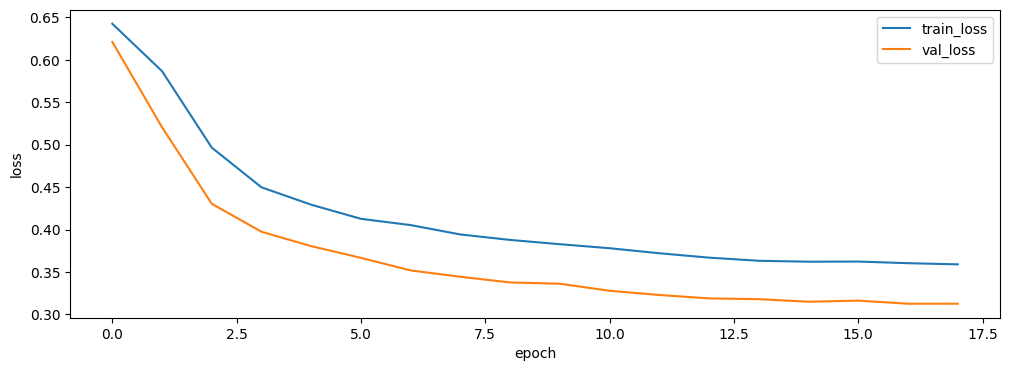

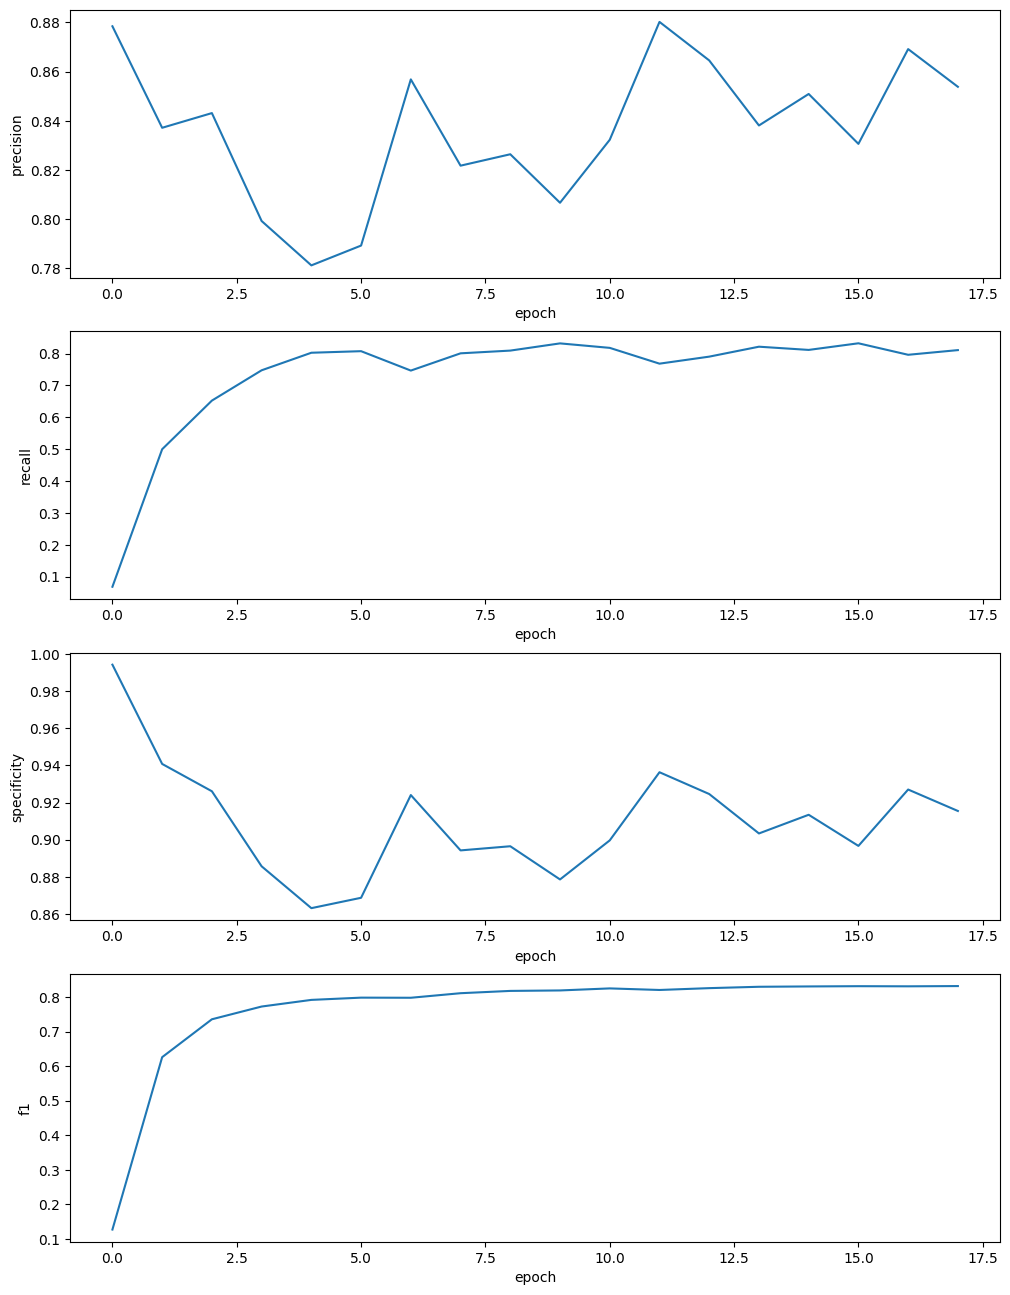

In [14]:
model.plot_history()

In [ ]:
try:
    model = model.load_best_model()
except FileNotFoundError:
    model = model.load_best_model('bert_binary/best_ckpt.pt')

Model loaded from epoch 18


In [16]:
for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.pooler.parameters():
    param.requires_grad = True

epochs = 18
early_stopping = 7

model.set_loss_fn(nn.BCELoss())
model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
total_steps = len(train_dataloader) * epochs
model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
                                            num_warmup_steps = 0.1 * total_steps,
                                            num_training_steps = total_steps))

model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, val_metric = 'f1', early_stopping=early_stopping)

100%|██████████| 136/136 [00:14<00:00,  9.40it/s]


  19    |    -    | train_loss   0.330071   | val_loss  0.247356  | precision  0.9027   | recall  0.8282   | specificity  0.9456   | f1  0.8638   |   59.39  


100%|██████████| 136/136 [00:14<00:00,  9.42it/s]


  20    |    -    | train_loss   0.285104   | val_loss  0.219856  | precision  0.9227   | recall  0.8316   | specificity  0.9575   | f1  0.8747   |   59.37  


100%|██████████| 136/136 [00:14<00:00,  9.38it/s]


...

  33    |    -    | train_loss   0.222505   | val_loss  0.182359  | precision  0.9054   | recall  0.8951   | specificity  0.9430   | f1  0.9002   |   59.05  


100%|██████████| 136/136 [00:14<00:00,  9.45it/s]


  34    |    -    | train_loss   0.226345   | val_loss  0.182719  | precision  0.9098   | recall  0.8851   | specificity  0.9466   | f1  0.8973   |   59.04  


100%|██████████| 136/136 [00:14<00:00,  9.41it/s]


  35    |    -    | train_loss   0.224135   | val_loss  0.183298  | precision  0.9151   | recall  0.8802   | specificity  0.9503   | f1  0.8973   |   59.31  


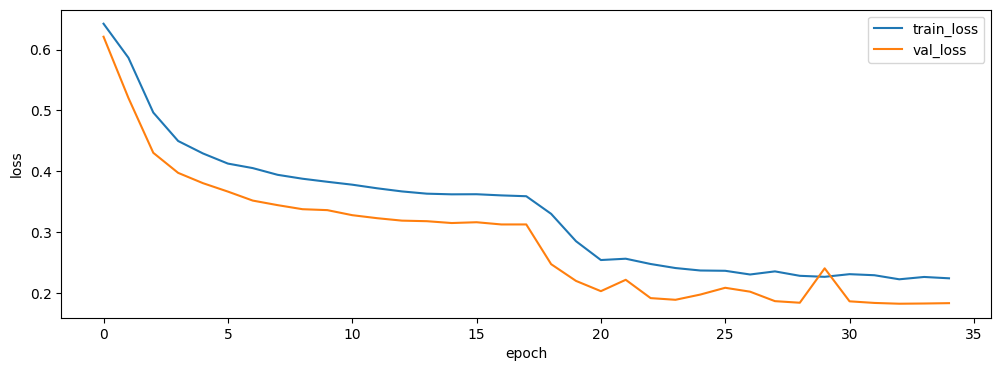

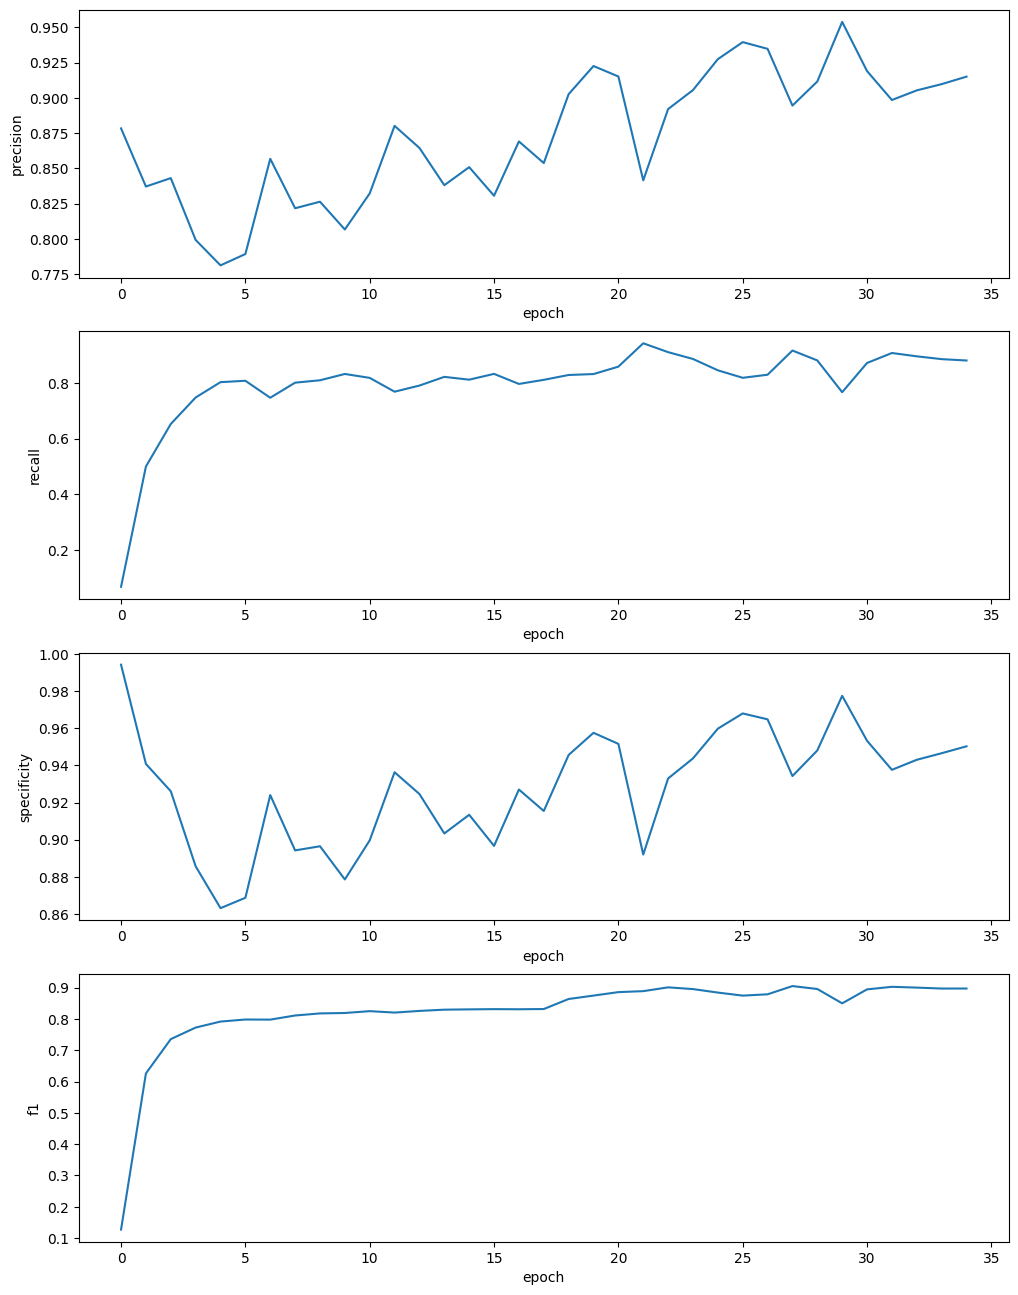

In [17]:
model.plot_history()

In [ ]:
try:
    model = model.load_best_model()
except FileNotFoundError:
    model = model.load_best_model('bert_binary/best_ckpt.pt')

Model loaded from epoch 28


In [19]:
for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.pooler.parameters():
    param.requires_grad = True

for layer in model.bert.encoder.layer:
    for param in layer.output.parameters():
        param.requires_grad = True

epochs = 18
early_stopping = 7

model.set_loss_fn(nn.BCELoss())
model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
total_steps = len(train_dataloader) * epochs
model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
                                            num_warmup_steps = 0.1 * total_steps,
                                            num_training_steps = total_steps))

model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

100%|██████████| 136/136 [00:14<00:00,  9.39it/s]


  29    |    -    | train_loss   0.186417   | val_loss  0.129990  | precision  0.9368   | recall  0.9285   | specificity  0.9618   | f1  0.9326   |  116.60  


100%|██████████| 136/136 [00:14<00:00,  9.43it/s]


  30    |    -    | train_loss   0.144691   | val_loss  0.105238  | precision  0.9400   | recall  0.9581   | specificity  0.9628   | f1  0.9490   |  116.63  


100%|██████████| 136/136 [00:14<00:00,  9.43it/s]


...

  44    |    -    | train_loss   0.006378   | val_loss  0.858720  | precision  0.9495   | recall  0.9606   | specificity  0.9689   | f1  0.9550   |  117.11  


100%|██████████| 136/136 [00:14<00:00,  9.33it/s]


  45    |    -    | train_loss   0.005142   | val_loss  0.904880  | precision  0.9503   | recall  0.9590   | specificity  0.9695   | f1  0.9547   |  116.98  


100%|██████████| 136/136 [00:14<00:00,  9.34it/s]


  46    |    -    | train_loss   0.005438   | val_loss  0.904234  | precision  0.9527   | recall  0.9551   | specificity  0.9711   | f1  0.9539   |  117.10  


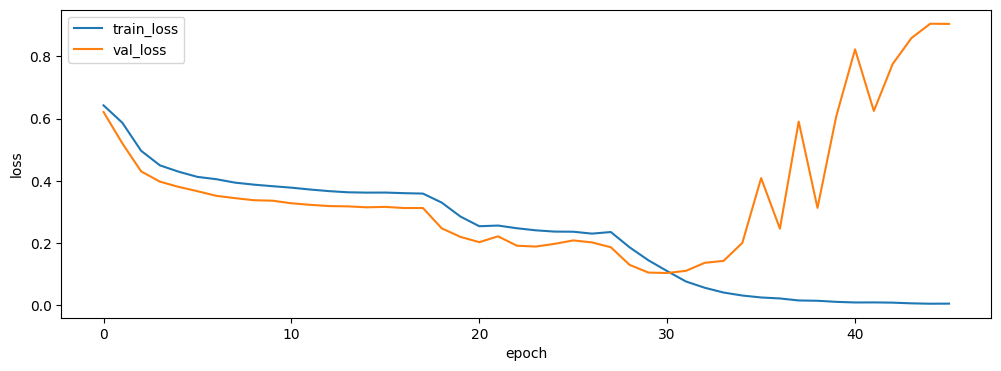

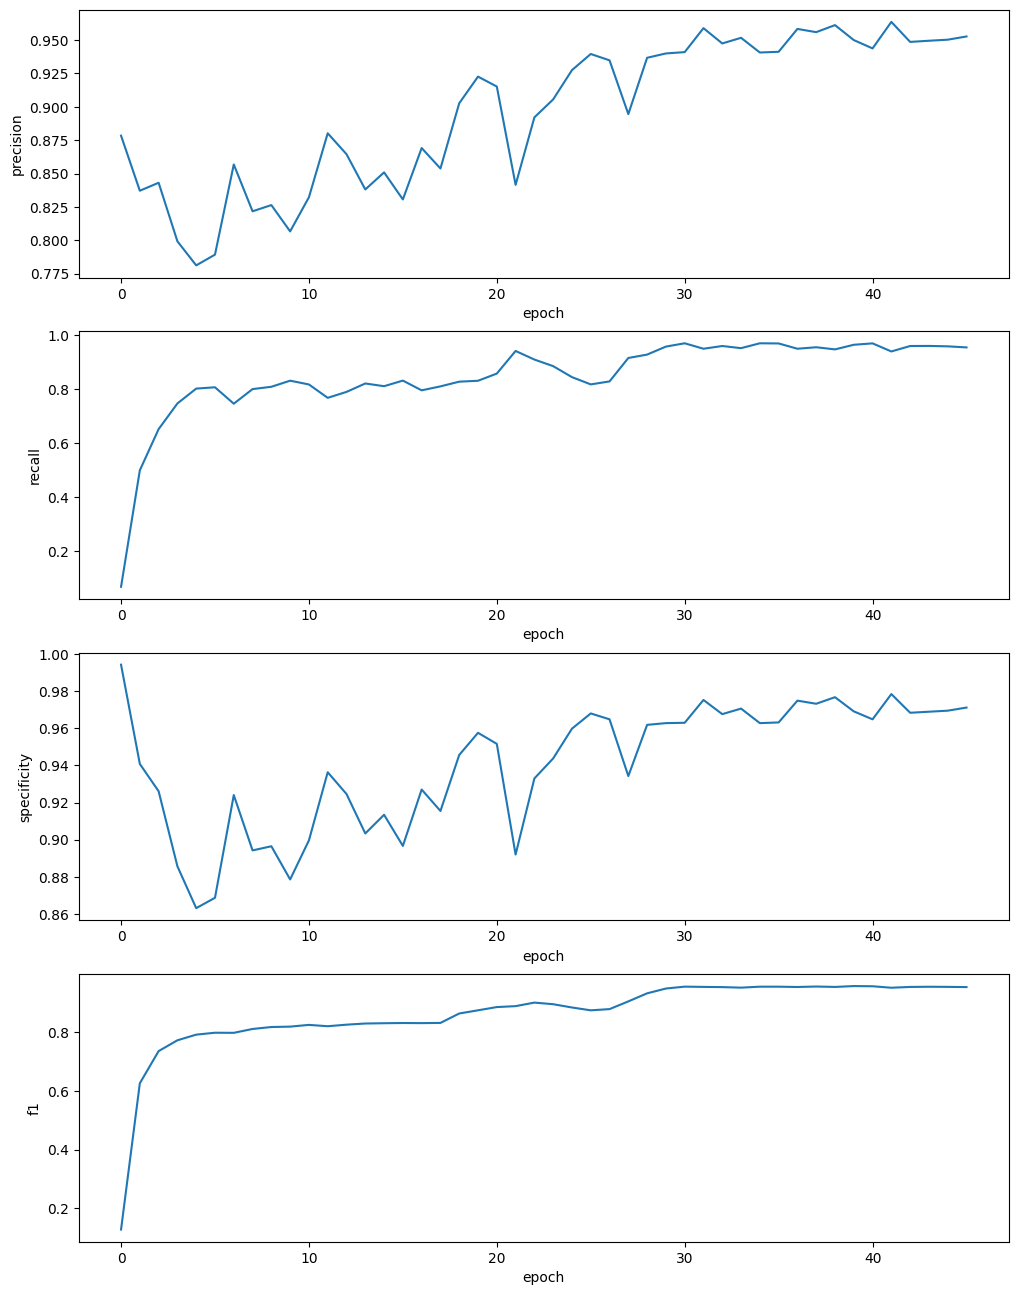

In [20]:
model.plot_history()

## Evaluation

In [ ]:
try:
    model = model.load_best_model()
except FileNotFoundError:
    model = model.load_best_model('bert_binary/best_ckpt.pt')

Model loaded from epoch 40


In [22]:
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=1)

In [23]:
pred = model.predict(val_dataloader)
y_true = np.array(val_labels)

100%|██████████| 8642/8642 [01:07<00:00, 127.80it/s]


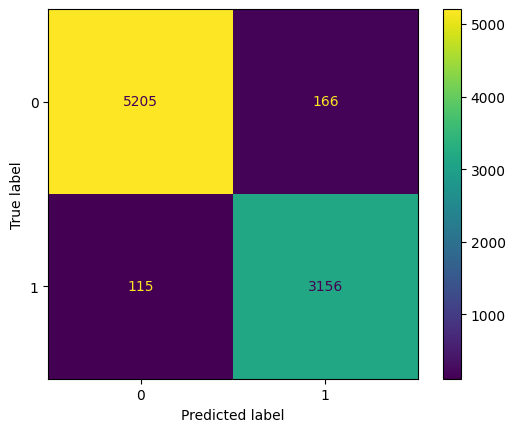

In [24]:
cm = confusion_matrix(y_true, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

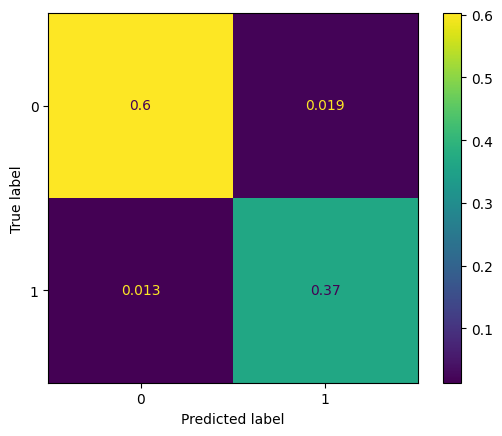

In [25]:
cm = confusion_matrix(y_true, pred, normalize='all')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()